Univerzitet u Sarajevu
<br> Elektrotehnički fakultet
#### **Predmet: Multimedijalni Sistemi**

# Laboratorijska vježba 10: Koraci JPEG dekompresije

Za izradu laboratorijske vježbe treba koristiti odgovarajuću Jupyter Notebook datoteku. Urađenu vježbu je potrebno konvertirati u PDF format, a zatim je PDF datoteku potrebno predati do postavljenog roka koristeći platformu Zamger.

Ime i prezime studenta, broj indeksa: Ismar Muslić, 2366/19304

Datum izrade izvještaja: 27.5.2026.

---

## Zadatak 1.

Potrebno je implementirati funkciju <code>JPEGDekomp(QDCTKoef)</code> koja kao ulazni argument prima matricu kvantiziranih DCT koeficijenata *QDCTKoef* dimenzija 8x8, te izvodi sljedeće korake JPEG dekompresije:

1. Koristeći kvantizacijsku tabelu <code>Q</code> definiranu u kodu iznad, prvo se izvodi dekvantizacija na sljedeći način:

<code>DQDCTKoef[i][j] = round(QDCTKoef[i][j] * Q[i][j])</code>

Dakle, kao rezultat se prvo dobivaju dekvantizirani DCT koeficijenti pohranjeni u matrici *DQDCTKoef*.

2. Nad dekvantiziranim DCT koeficijentima *DQDCTKoef* se izvodi dvodimenzionalna inverzna diskretna kosinusna transformacija (IDCT), što rezultira matricom koja sadrži reducirane (-128) vrijednosti intenziteta piksela bloka *B*. Za izvođenje IDCT koristite funkciju <code>idct</code> iz modula *scipy.fftpack* (<code>from scipy.fftpack import idct</code>). Dvodimenzionalnu IDCT nad *DQDCTKoef* možete dobiti na sljedeći način: <code>idct(idct(DQDCTKoef, axis = 0, norm = 'ortho'), axis = 1, norm = 'ortho').astype(int)</code>. Primijetite da je funkcija <code>idct</code> pozvana dva puta imajući u vidu da jedan poziv ove funkcije izvodi IDCT samo u jednoj dimenziji. Isto tako, primijetite da je napravljena konverzija u cjelobrojne vrijednosti.


3. Dobivenim reduciranim vrijednostima piksela nakon izvedene IDCT dodati vrijednost 128.

Kao rezultat funkcija <code>JPEGDekomp(QDCTKoef)</code> vraća matricu u kojoj su pohranjene rekonstruirane vrijednosti intenziteta piksela originalnog bloka *B*.

Detaljan opis koraka JPEG dekompresije možete naći u PDFmaterijalima na platformi C2 (poglavlje 6, str. 145-166).

**Rješenje:**

In [ ]:
import numpy as np
import copy
import cv2
from matplotlib import pyplot
from matplotlib import image as mpimage
from scipy.fftpack import dct
from scipy.fftpack import idct

In [ ]:

Q = [
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
]

### Neophodni kod sa LV9

In [ ]:
def JPEGKomp(B):
    B_shifted = B.astype(float) - 128

    DCTKoef = dct(dct(B_shifted, axis=0, norm='ortho'), axis=1, norm='ortho').astype(int)

    QDCTKoef = np.round(DCTKoef / Q).astype(int)

    return DCTKoef, QDCTKoef

Testna slika: 
Crvenom bojom  označen blok B1. 
Zelenom bojom označen blok B2. 
Plavom bojom označen blok B3.



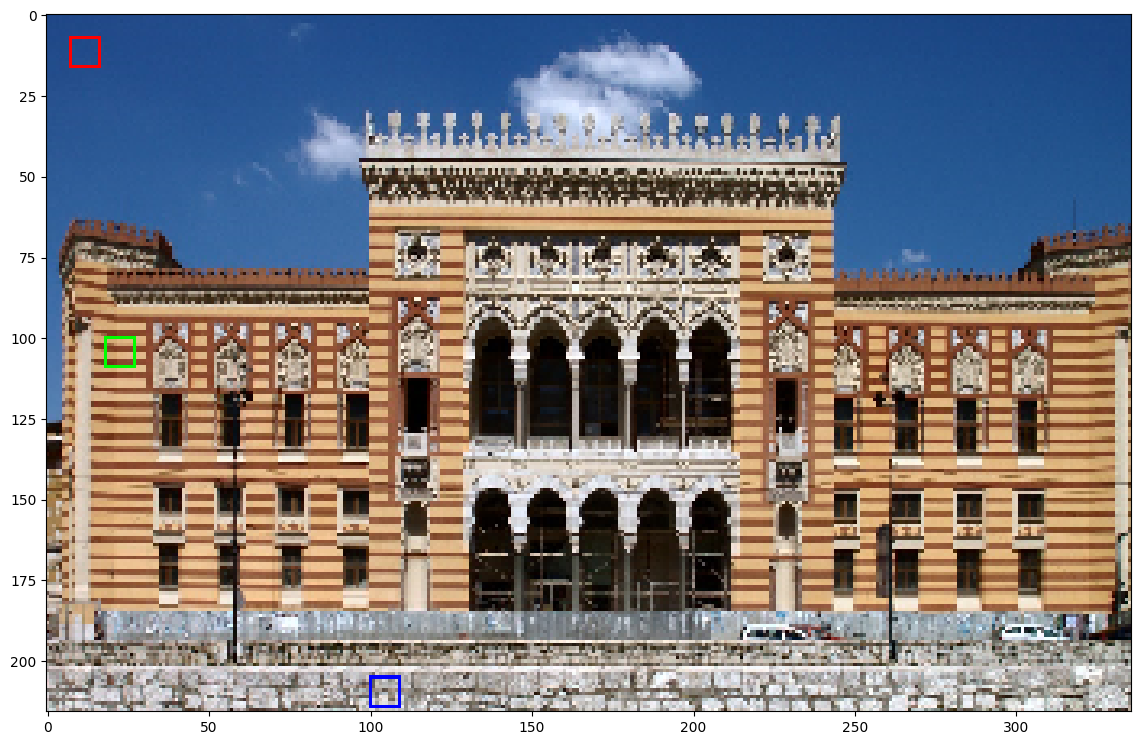

In [ ]:
path = "../LV9/Vijecnica.bmp"
image = mpimage.imread(path).copy()

height, width, channels = image.shape
pocetak1 = (7,7)
kraj1 = (16,16)
boja1 = (255,0,0)
debljina = 1
image = cv2.rectangle(image, pocetak1, kraj1, boja1, debljina)

pocetak2 = (18,100)
kraj2 = (27,109)
boja2 = (0,255,0)
image = cv2.rectangle(image, pocetak2, kraj2, boja2, debljina)

pocetak3 = (100, 205)
kraj3 = (109, 214)
boja3 = (0,0,255)
image = cv2.rectangle(image, pocetak3, kraj3, boja3, debljina)

print("Testna slika: \nCrvenom bojom  označen blok B1. \nZelenom bojom označen blok B2. \nPlavom bojom označen blok B3.\n")

pyplot.figure(figsize = (14,10))
pyplot.imshow(image)
pyplot.show()

B1=copy.deepcopy(image[pocetak1[1]+1:kraj1[1],pocetak1[0]+1:kraj1[0]])

R, G, B = B1[:,:,0], B1[:,:,1], B1[:,:,2]
B1Y = (0.2989 * R + 0.5870 * G + 0.1140 * B).astype(int)

DCTKoef1,QDCTKoef1 = JPEGKomp(B1Y)


B2=copy.deepcopy(image[pocetak2[1]+1:kraj2[1],pocetak2[0]+1:kraj2[0]])

R, G, B = B2[:,:,0], B2[:,:,1], B2[:,:,2]
B2Y = (0.2989 * R + 0.5870 * G + 0.1140 * B).astype(int)
DCTKoef2,QDCTKoef2 = JPEGKomp(B2Y)


B3=copy.deepcopy(image[pocetak3[1]+1:kraj3[1],pocetak3[0]+1:kraj3[0]])

R, G, B = B3[:,:,0], B3[:,:,1], B3[:,:,2]
B3Y = (0.2989 * R + 0.5870 * G + 0.1140 * B).astype(int)
DCTKoef3,QDCTKoef3 = JPEGKomp(B3Y)

In [20]:
def JPEGDekomp(QDCTKoef):
    DQDCTKoef = np.round(QDCTKoef * Q).astype(int)

    rekonstruisano = idct(idct(DQDCTKoef.astype(float), axis=0, norm='ortho'), axis=1, norm='ortho').astype(int)

    rekonstruisano = rekonstruisano + 128

    return rekonstruisano


Nakon implementacije funkcije, potrebno je izvesti programski kod ispod koji se odnosi na blok B1, tako da se dobiju prikazani rezultati.


Grafički prikaz originalnih vrijednosti piksela za blok B1:



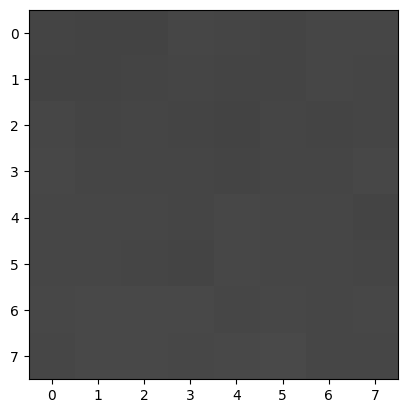


Grafički prikaz rekonstruiranih vrijednosti piksela za blok B1:



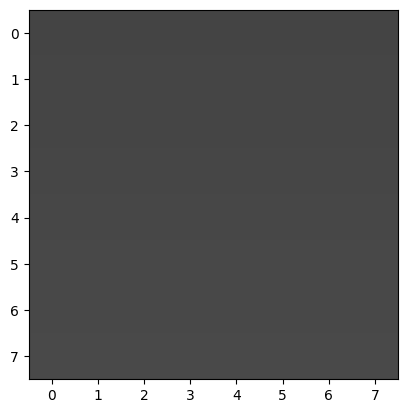


Vrijednosti intenziteta piksela za originalni blok B1:

[[68 67 67 70 69 68 70 70]
 [67 67 68 69 68 68 70 69]
 [70 68 69 68 67 69 68 69]
 [71 69 69 69 68 69 69 71]
 [70 70 70 69 71 70 70 68]
 [70 70 69 68 71 70 70 69]
 [71 72 72 72 70 71 70 71]
 [70 72 72 71 72 73 70 70]]

Rekonstruirane vrijednosti intenziteta piksela za blok B1:

[[68 68 68 68 68 68 68 68]
 [69 69 69 69 69 69 69 69]
 [69 69 69 69 69 69 69 69]
 [70 70 70 70 70 70 70 70]
 [71 71 71 71 71 71 71 71]
 [72 72 72 72 72 72 72 72]
 [72 72 72 72 72 72 72 72]
 [73 73 73 73 73 73 73 73]]

Greške rekonstrukcije vrijednosti piksela bloka B1

[[ 0 -1 -1  2  1  0  2  2]
 [-2 -2 -1  0 -1 -1  1  0]
 [ 1 -1  0 -1 -2  0 -1  0]
 [ 1 -1 -1 -1 -2 -1 -1  1]
 [-1 -1 -1 -2  0 -1 -1 -3]
 [-2 -2 -3 -4 -1 -2 -2 -3]
 [-1  0  0  0 -2 -1 -2 -1]
 [-3 -1 -1 -2 -1  0 -3 -3]]


In [21]:
RB1Y = JPEGDekomp(QDCTKoef1)

print("\nGrafički prikaz originalnih vrijednosti piksela za blok B1:\n")

pyplot.imshow(B1Y,cmap='gray',vmin=0,vmax=255)
pyplot.show()

print("\nGrafički prikaz rekonstruiranih vrijednosti piksela za blok B1:\n")

pyplot.imshow(RB1Y,cmap='gray',vmin=0,vmax=255)
pyplot.show()

print("\nVrijednosti intenziteta piksela za originalni blok B1:\n")
print(B1Y)

print("\nRekonstruirane vrijednosti intenziteta piksela za blok B1:\n")
print(RB1Y)

E1=B1Y-RB1Y
print("\nGreške rekonstrukcije vrijednosti piksela bloka B1\n")
print(E1)

Nadalje, potrebno je izvesti i programski kod ispod koji se odnosi na blok B2, tako da se dobiju prikazani rezultati. **Osim toga, potrebno je dodati i primjer rezultata dekompresije za proizvoljno odabrani blok B3 u prvom zadatku na isti način kako je to urađeno za blokove B1 i B2.**


Grafički prikaz originalnih vrijednosti piksela za blok B2:



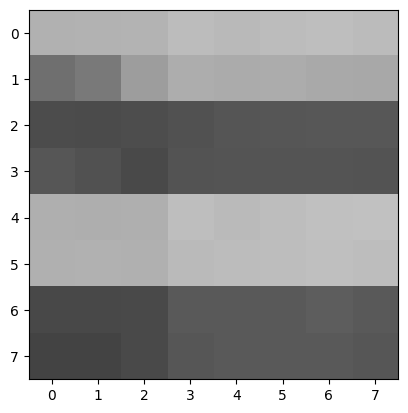


Grafički prikaz rekonstruiranih vrijednosti piksela za blok B2:



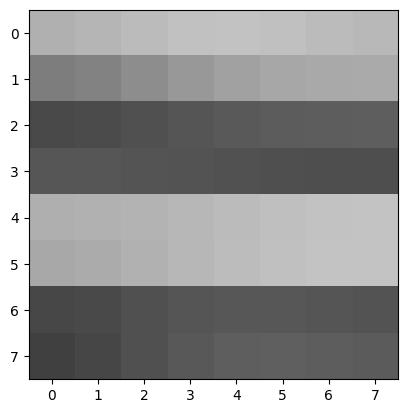


Vrijednosti intenziteta piksela za originalni blok B2:

[[177 178 179 188 185 188 190 187]
 [111 121 157 173 171 172 169 168]
 [ 76  75  77  81  85  86  87  87]
 [ 86  82  74  83  84  84  84  83]
 [175 174 175 190 186 189 192 193]
 [176 177 176 186 188 189 191 189]
 [ 72  72  74  90  89  89  93  89]
 [ 67  67  74  86  89  90  89  86]]

Rekonstruirane vrijednosti intenziteta piksela za blok B2:

[[176 181 187 193 194 192 187 184]
 [125 130 141 152 161 167 169 170]
 [ 73  75  80  85  89  92  93  94]
 [ 86  86  84  83  81  79  78  78]
 [175 177 179 183 187 191 194 195]
 [168 171 177 183 188 192 195 196]
 [ 71  74  80  85  87  87  85  83]
 [ 64  70  80  88  94  95  93  91]]

Greške rekonstrukcije vrijednosti piksela bloka B2

[[  1  -3  -8  -5  -9  -4   3   3]
 [-14  -9  16  21  10   5   0  -2]
 [  3   0  -3  -4  -4  -6  -6  -7]
 [  0  -4 -10   0   3   5   6   5]
 [  0  -3  -4   7  -1  -2  -2  -2]
 [  8   6  -1   3   0  -3  -4  -7]
 [  1  -2  -6   5   2   2   8   6]
 [  3  -3  -6  -2  -5 

In [22]:
# Blok B2
RB2Y = JPEGDekomp(QDCTKoef2)

print("\nGrafički prikaz originalnih vrijednosti piksela za blok B2:\n")

pyplot.imshow(B2Y,cmap='gray',vmin=0,vmax=255)
pyplot.show()
print("\nGrafički prikaz rekonstruiranih vrijednosti piksela za blok B2:\n")

pyplot.imshow(RB2Y,cmap='gray',vmin=0,vmax=255)
pyplot.show()

print("\nVrijednosti intenziteta piksela za originalni blok B2:\n")
print(B2Y)

print("\nRekonstruirane vrijednosti intenziteta piksela za blok B2:\n")
print(RB2Y)


E2=B2Y-RB2Y
print("\nGreške rekonstrukcije vrijednosti piksela bloka B2\n")
print(E2)




Grafički prikaz originalnih vrijednosti piksela za blok B3:



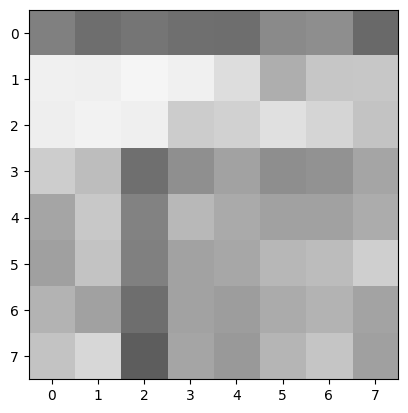


Grafički prikaz rekonstruiranih vrijednosti piksela za blok B3:



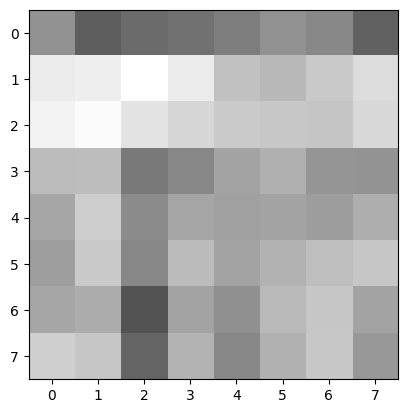


Vrijednosti intenziteta piksela za originalni blok B3:

[[128 110 117 111 110 138 142 106]
 [240 239 245 240 221 174 198 199]
 [238 242 239 204 209 224 213 195]
 [205 189 111 143 162 142 146 165]
 [165 200 130 184 170 161 161 172]
 [160 196 128 162 167 183 188 207]
 [179 161 110 162 157 171 180 164]
 [196 215  93 165 153 181 197 160]]

Rekonstruirane vrijednosti intenziteta piksela za blok B3:

[[146  94 107 114 125 145 136  98]
 [235 238 258 235 193 184 201 220]
 [243 251 228 214 202 199 197 216]
 [188 189 121 135 164 176 149 147]
 [166 205 139 165 160 164 157 174]
 [158 201 135 187 163 178 190 198]
 [166 172  83 163 144 185 198 164]
 [207 198 100 179 135 177 199 152]]

Greške rekonstrukcije vrijednosti piksela bloka B3

[[-18  16  10  -3 -15  -7   6   8]
 [  5   1 -13   5  28 -10  -3 -21]
 [ -5  -9  11 -10   7  25  16 -21]
 [ 17   0 -10   8  -2 -34  -3  18]
 [ -1  -5  -9  19  10  -3   4  -2]
 [  2  -5  -7 -25   4   5  -2   9]
 [ 13 -11  27  -1  13 -14 -18   0]
 [-11  17  -7 -14  18 

In [23]:
# Blok B3
RB3Y = JPEGDekomp(QDCTKoef3)

print("\nGrafički prikaz originalnih vrijednosti piksela za blok B3:\n")

pyplot.imshow(B3Y,cmap='gray',vmin=0,vmax=255)
pyplot.show()
print("\nGrafički prikaz rekonstruiranih vrijednosti piksela za blok B3:\n")

pyplot.imshow(RB3Y,cmap='gray',vmin=0,vmax=255)
pyplot.show()

print("\nVrijednosti intenziteta piksela za originalni blok B3:\n")
print(B3Y)

print("\nRekonstruirane vrijednosti intenziteta piksela za blok B3:\n")
print(RB3Y)


E3=B3Y-RB3Y
print("\nGreške rekonstrukcije vrijednosti piksela bloka B3\n")
print(E3)